# 04 · Leiden clustering & Tsoi-state annotation  *(Stage 2 climax)*

**Goal (Q2.4).** Cluster the Harmony-corrected malignant cells with Leiden
at several resolutions, then — *by human judgment, not by code* — label
clusters with the Tsoi 2018 four states using `MITF/SOX10/NGFR/AXL`.

If this reproduces Balderson 2024's four states → we replicated their core
finding with a methodological upgrade (Harmony + Leiden). If it does **not**
→ that is itself a real finding (a limitation of Balderson, or
over-correction). Either outcome is a core deliverable.

> **HARD RULE.** Claude computes expression and draws plots. **Which cluster
> is which Tsoi state is the student's biological judgment** and is filled
> into the clearly-marked *STUDENT DECISION* cell. The annotation / final
> figure / save cells are guarded and stay inert until that cell is filled —
> the notebook never invents a label.

### Design decisions (recorded before code)

1. **Leiden, not Louvain** (Traag et al. 2019 — Leiden fixes Louvain's
   badly-connected communities; scanpy/Seurat default). Balderson used
   Monocle trajectory inference, so Leiden is already a method upgrade.
   Called with `flavor="igraph", n_iterations=2` (scanpy's modern,
   warning-free recommended path).
2. **Resolution sweep** `[0.1, 0.2, 0.3, 0.5, 0.8, 1.0]`, each stored in
   `obs['leiden_r{res}']`. We do **not** tune toward 4 clusters — that would
   be confirmation bias; we let the data speak and pick by evidence.
3. **Dual diagnostic per resolution: dotplot + cluster×patient crosstab.**
   The crosstab is the *more important* gate: a cluster that is >90% one
   patient is almost certainly residual batch, not a biological state — even
   if its dotplot superficially matches a Tsoi pattern. Legitimacy of a
   Tsoi label needs *both* (marker pattern AND multi-patient support).
4. **Clusters matching no Tsoi state get `Other`/`Ambiguous`** — admitting
   ignorance beats forcing a label (doublets, transitional cells, noise,
   or batch).

## Step 0 — Imports & paths

In [1]:
import logging, warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import date
from importlib.metadata import version

%matplotlib inline
sc.settings.verbosity = 1

def _resolve(*candidates):
    for c in candidates:
        p = Path(c)
        if p.exists() or p.parent.exists():
            return p
    return Path(candidates[0])

PROC   = _resolve("../data/processed", "data/processed")
FIGDIR = _resolve("../results/figures", "results/figures")
FIGDIR.mkdir(parents=True, exist_ok=True)
sc.settings.figdir = FIGDIR

IN_H5AD  = PROC / "tirosh_malignant_harmony.h5ad"
OUT_H5AD = PROC / "tirosh_malignant_annotated.h5ad"
assert IN_H5AD.exists(), f"Run notebook 03 first; missing {IN_H5AD}"

MARKERS     = ["MITF", "SOX10", "NGFR", "AXL"]
RESOLUTIONS = [0.1, 0.2, 0.3, 0.5, 0.8, 1.0]

print("scanpy", version("scanpy"), "| leidenalg", version("leidenalg"),
      "| numpy", version("numpy"))
print("in :", IN_H5AD.resolve())
print("out:", OUT_H5AD.resolve())

scanpy 1.11.5 | leidenalg 0.10.2 | numpy 2.4.5
in : /Users/youyouwu/Desktop/melanoma-scrnaseq-reanalysis/data/processed/tirosh_malignant_harmony.h5ad
out: /Users/youyouwu/Desktop/melanoma-scrnaseq-reanalysis/data/processed/tirosh_malignant_annotated.h5ad


## Step 1 — Load & rebuild the Harmony neighbour graph

We recompute neighbours on `X_pca_harmony` (n_pcs=30) explicitly so the
clustering provenance is unambiguous, rather than relying on the graph
stored in the file.

In [2]:
adata = sc.read_h5ad(IN_H5AD)
sc.pp.neighbors(adata, use_rep="X_pca_harmony", n_neighbors=15, n_pcs=30,
                random_state=0)
print("loaded:", adata.shape, "| obsm:", sorted(adata.obsm))
assert all(m in adata.var_names for m in MARKERS), "Tsoi markers missing"

loaded: (1257, 23686) | obsm: ['X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_uncorrected']


## Step 2 — Multi-resolution Leiden

In [3]:
for res in RESOLUTIONS:
    key = f"leiden_r{res}"
    sc.tl.leiden(adata, resolution=res, key_added=key,
                 flavor="igraph", n_iterations=2, directed=False,
                 random_state=0)

summary = pd.DataFrame({
    "resolution": RESOLUTIONS,
    "n_clusters": [adata.obs[f"leiden_r{r}"].nunique() for r in RESOLUTIONS],
})
print(summary.to_string(index=False))

 resolution  n_clusters
        0.1           3
        0.2           5
        0.3           6
        0.5           9
        0.8          11
        1.0          15


## Step 3 — UMAP grid across resolutions

Eyeball how cluster granularity changes with resolution.

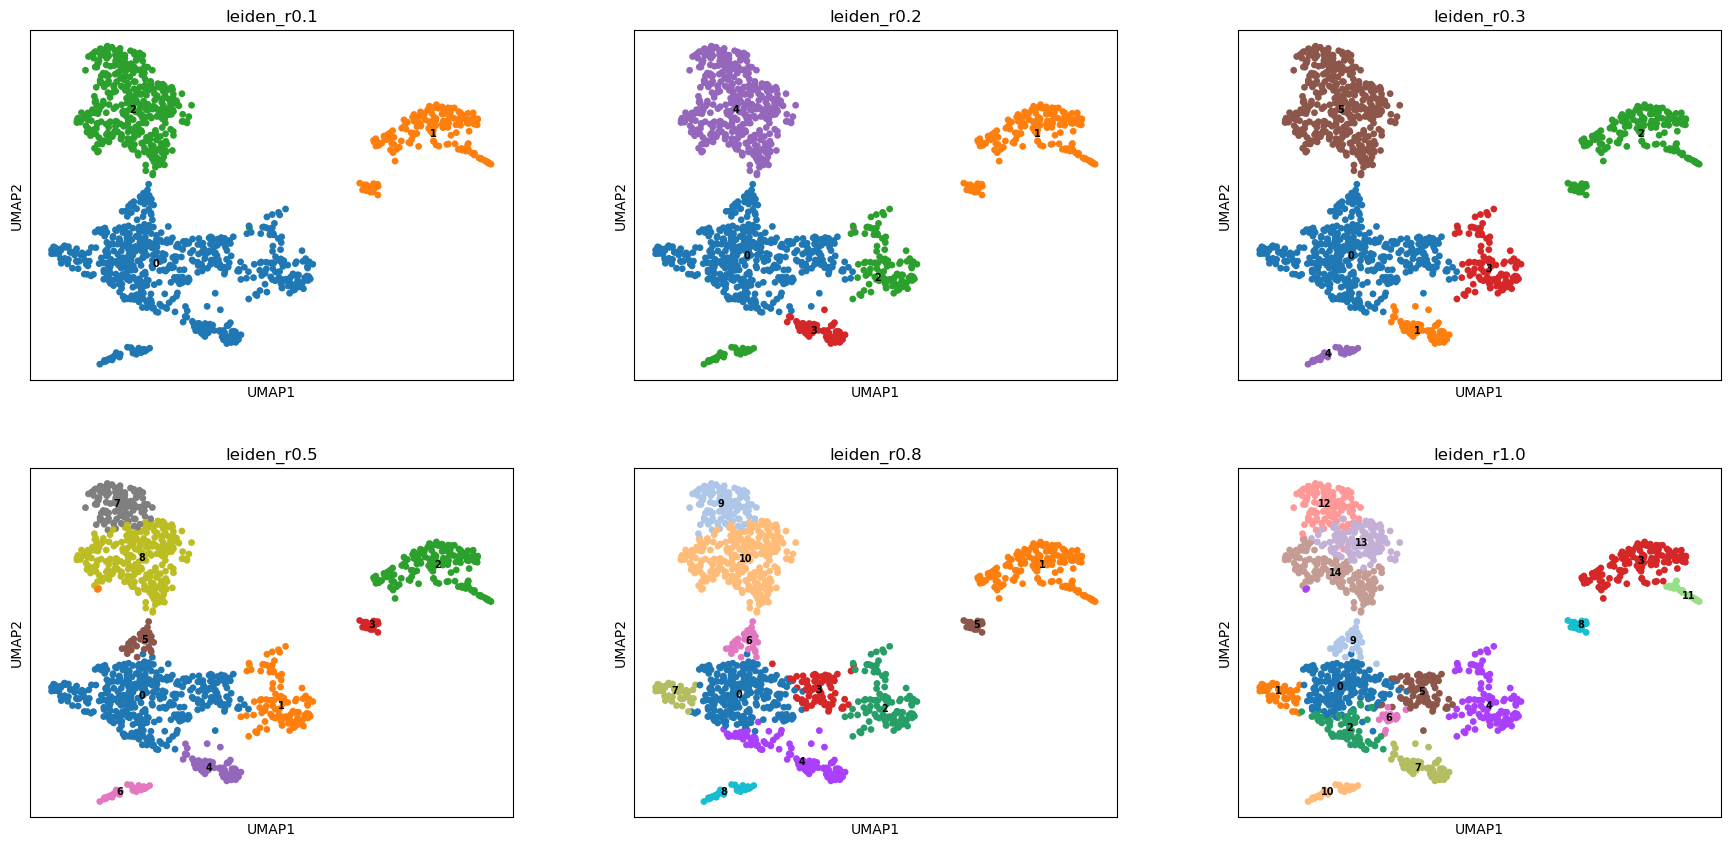

In [4]:
keys = [f"leiden_r{r}" for r in RESOLUTIONS]
sc.pl.umap(adata, color=keys, ncols=3, legend_loc="on data",
           legend_fontsize=7, show=False)
plt.savefig(FIGDIR / "04_leiden_umap_grid.png", dpi=120, bbox_inches="tight")
plt.show(); plt.close()

## Step 4 — Tsoi-marker dotplots per resolution

Each dot: mean `log2(TPM/10+1)` (color) and fraction expressing (size) of
`MITF/SOX10/NGFR/AXL` per cluster. This shows the *pattern*; assigning a
Tsoi name to a pattern is the student's call (Step 6).

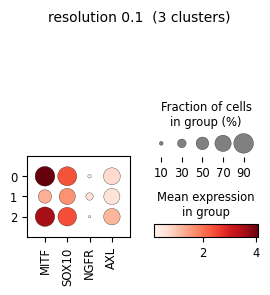

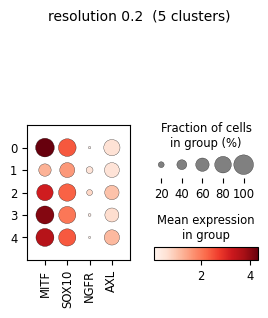

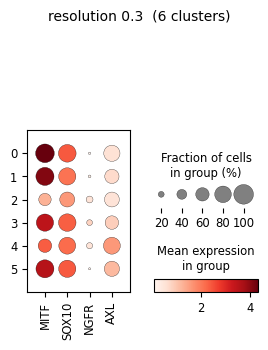

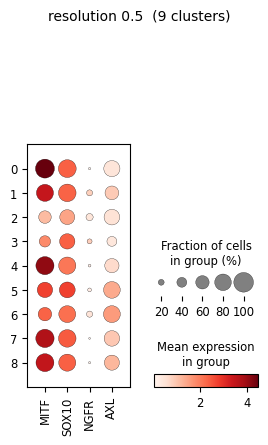

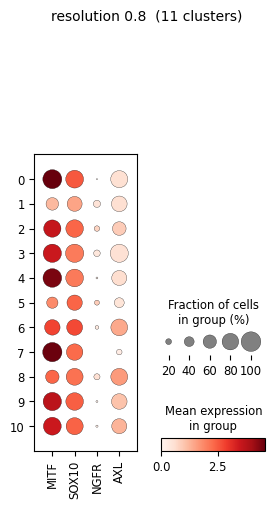

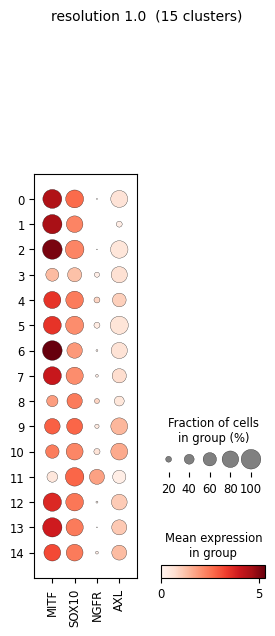

In [5]:
for res in RESOLUTIONS:
    key = f"leiden_r{res}"
    sc.pl.dotplot(adata, MARKERS, groupby=key, show=False)
    plt.suptitle(f"resolution {res}  ({adata.obs[key].nunique()} clusters)",
                 y=1.02, fontsize=10)
    plt.savefig(FIGDIR / f"04_dotplot_r{res}.png", dpi=120,
                bbox_inches="tight")
    plt.show(); plt.close()

## Step 5 — cluster × patient crosstab  *(the key quality gate)*

For every resolution: the count crosstab, plus, per cluster, the **max
single-patient fraction**. Flags:

- `>0.90` → ⚠️ **patient-dominated → likely residual batch, NOT a state**
- `0.70–0.90` → ◐ patient-skewed (interpret cautiously)
- `<0.70` → ✓ multi-patient supported

A Tsoi label is only legitimate if the cluster has *both* a clean marker
pattern (Step 4) *and* multi-patient support (here).


=== resolution 0.1  (3 clusters) ===
             n_cells  max_patient_frac  dominant_patient               flag
leiden_r0.1                                                                
0                660              0.18                80        ok multi-pt
1                179              0.73                81     skew 0.70-0.90
2                418              1.00                79  WARN >0.90 batch?


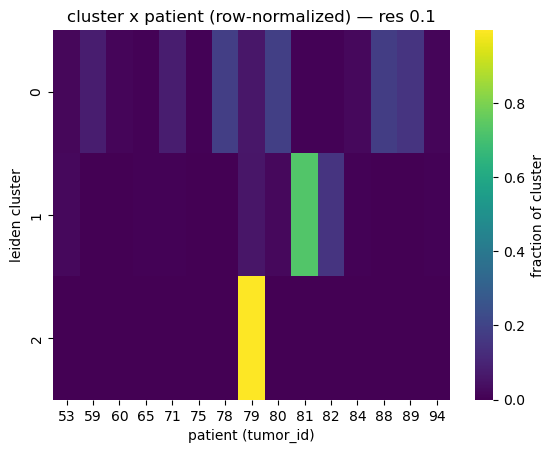


=== resolution 0.2  (5 clusters) ===
             n_cells  max_patient_frac  dominant_patient               flag
leiden_r0.2                                                                
0                454              0.24                88        ok multi-pt
1                179              0.73                81     skew 0.70-0.90
2                140              0.60                80        ok multi-pt
3                 66              0.35                80        ok multi-pt
4                418              1.00                79  WARN >0.90 batch?


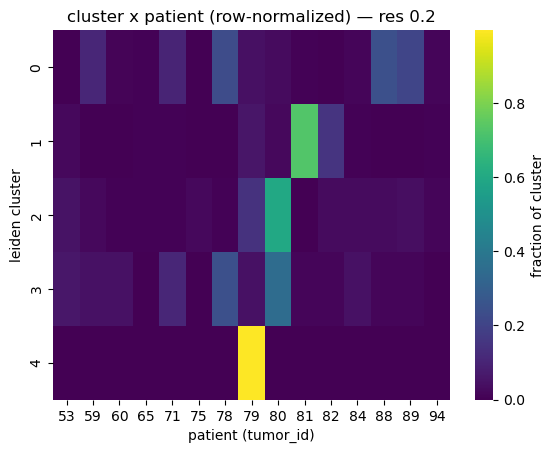


=== resolution 0.3  (6 clusters) ===
             n_cells  max_patient_frac  dominant_patient               flag
leiden_r0.3                                                                
0                451              0.25                88        ok multi-pt
1                 69              0.36                80        ok multi-pt
2                179              0.73                81     skew 0.70-0.90
3                107              0.78                80     skew 0.70-0.90
4                 33              0.21                79        ok multi-pt
5                418              1.00                79  WARN >0.90 batch?


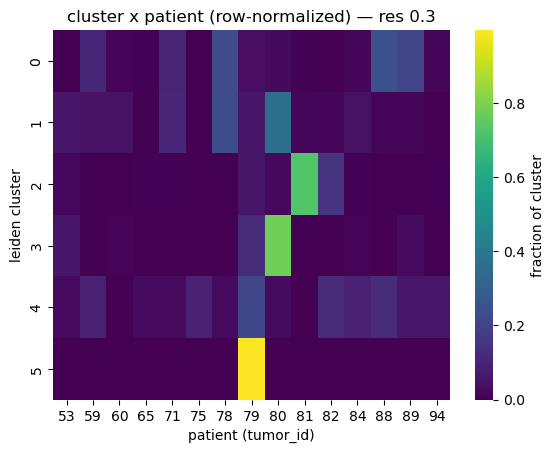


=== resolution 0.5  (9 clusters) ===
             n_cells  max_patient_frac  dominant_patient               flag
leiden_r0.5                                                                
0                413              0.23                88        ok multi-pt
1                111              0.77                80     skew 0.70-0.90
2                154              0.83                81     skew 0.70-0.90
3                 25              0.40                79        ok multi-pt
4                 69              0.36                80        ok multi-pt
5                 36              0.39                88        ok multi-pt
6                 33              0.21                79        ok multi-pt
7                123              1.00                79  WARN >0.90 batch?
8                293              1.00                79  WARN >0.90 batch?


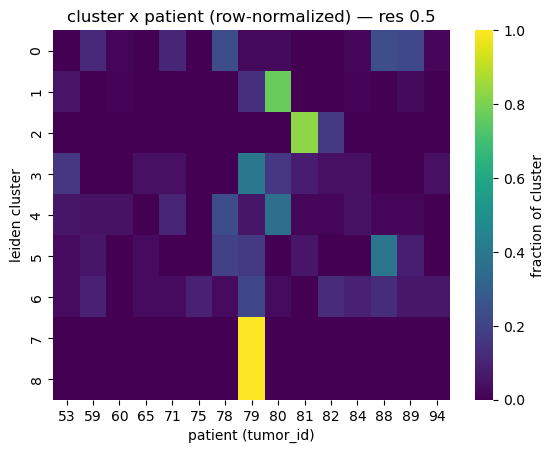


=== resolution 0.8  (11 clusters) ===
             n_cells  max_patient_frac  dominant_patient               flag
leiden_r0.8                                                                
0                252              0.38                88        ok multi-pt
1                154              0.83                81     skew 0.70-0.90
2                109              0.79                80     skew 0.70-0.90
3                 77              0.83                89     skew 0.70-0.90
4                110              0.40                78        ok multi-pt
5                 25              0.40                79        ok multi-pt
6                 37              0.38                88        ok multi-pt
7                 43              0.86                59     skew 0.70-0.90
8                 33              0.21                79        ok multi-pt
9                125              1.00                79  WARN >0.90 batch?
10               292              1.00           

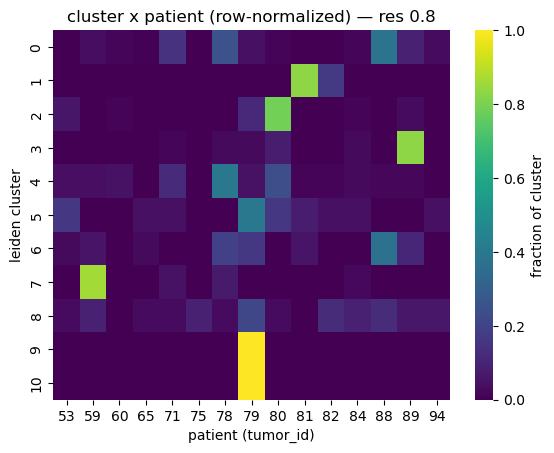


=== resolution 1.0  (15 clusters) ===
             n_cells  max_patient_frac  dominant_patient               flag
leiden_r1.0                                                                
0                190              0.46                88        ok multi-pt
1                 45              0.82                59     skew 0.70-0.90
2                 75              0.79                78     skew 0.70-0.90
3                127              1.00                81  WARN >0.90 batch?
4                113              0.76                80     skew 0.70-0.90
5                 78              0.82                89     skew 0.70-0.90
6                 22              0.59                71        ok multi-pt
7                 69              0.36                80        ok multi-pt
8                 25              0.40                79        ok multi-pt
9                 38              0.37                88        ok multi-pt
10                33              0.21           

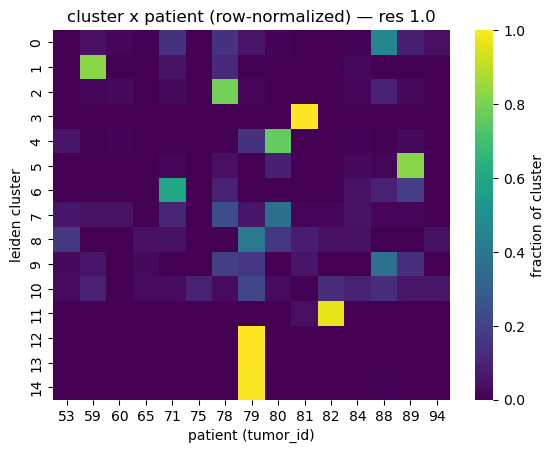

In [6]:
for res in RESOLUTIONS:
    key = f"leiden_r{res}"
    ct = pd.crosstab(adata.obs[key], adata.obs["tumor_id"])
    frac = ct.div(ct.sum(1), axis=0)
    maxfrac = frac.max(1)
    dom = frac.idxmax(1)
    flag = maxfrac.map(lambda v: "WARN >0.90 batch?" if v > 0.90
                       else ("skew 0.70-0.90" if v > 0.70 else "ok multi-pt"))
    rep = pd.DataFrame({"n_cells": ct.sum(1),
                        "max_patient_frac": maxfrac.round(2),
                        "dominant_patient": dom, "flag": flag})
    print(f"\n=== resolution {res}  ({ct.shape[0]} clusters) ===")
    print(rep.to_string())
    sns.heatmap(frac, cmap="viridis", cbar_kws={"label": "fraction of cluster"})
    plt.title(f"cluster x patient (row-normalized) — res {res}")
    plt.xlabel("patient (tumor_id)"); plt.ylabel("leiden cluster")
    plt.savefig(FIGDIR / f"04_crosstab_r{res}.png", dpi=120,
                bbox_inches="tight")
    plt.show(); plt.close()

## Step 6 — STUDENT DECISION  *(fill this in — your biological judgment)*

Read Step 4 (dotplots) **and** Step 5 (crosstab flags) together, then set
the two variables below.

**Tsoi 2018 four-state rule**

| State | MITF | SOX10 | NGFR | AXL |
|---|---|---|---|---|
| Melanocytic | ↑ | ↑ | ↓ | ↓ |
| Transitory | ↑ | ↑ | ↑ | ↓ |
| Neural crest-like | ↓ | ↑ | ↑ | ↑ |
| Undifferentiated | ↓ | ↓ | ↓ | ↑ |

Rules:
- Pick the resolution whose clusters best match distinct Tsoi patterns
  *and* are multi-patient supported.
- A cluster flagged `WARN >0.90 batch?` → label `"Other (batch?)"`, do not
  force a state.
- A cluster matching no state → `"Ambiguous"`. Note *why* in a comment.
- **Every** cluster id at the chosen resolution must appear in the mapping
  (the next cell asserts completeness).

In [7]:
# ============= STUDENT DECISION (filled by the author) ===================
# Biological judgment from the dotplot + cluster x patient crosstab at
# res=0.3. Full per-cluster rationale is in the final markdown cell.
CHOSEN_RES   = "0.3"
TSOI_MAPPING = {
    "0": "Melanocytic",
    "1": "Melanocytic",
    "2": "Other (batch?)",
    "3": "Other (batch?)",
    "4": "Undifferentiated",
    "5": "Other (batch?)",
}
# ==========================================================================
print("CHOSEN_RES =", CHOSEN_RES, "| clusters mapped:", len(TSOI_MAPPING))

CHOSEN_RES = 0.3 | clusters mapped: 6


## Step 7 — Apply annotation  *(guarded)*

Runs only once Step 6 is filled; otherwise prints a waiting message so the
notebook still executes end-to-end on the diagnostics alone.

In [8]:
if CHOSEN_RES is not None and TSOI_MAPPING is not None:
    key = f"leiden_r{CHOSEN_RES}"
    clusters = set(adata.obs[key].cat.categories)
    missing = clusters - set(TSOI_MAPPING)
    assert not missing, f"TSOI_MAPPING missing clusters: {sorted(missing)}"
    _ORDER = ["Melanocytic", "Transitory", "Neural crest-like",
              "Undifferentiated", "Ambiguous", "Other (batch?)"]
    used = [s for s in _ORDER if s in set(TSOI_MAPPING.values())]
    adata.obs["tsoi_state"] = (adata.obs[key].map(TSOI_MAPPING)
                               .astype("category")
                               .cat.reorder_categories(used))
    adata.uns["q24"] = {"chosen_resolution": CHOSEN_RES,
                        "mapping": TSOI_MAPPING,
                        "leiden_flavor": "igraph",
                        "built": str(date.today())}
    print("tsoi_state assigned from", key)
    print(adata.obs["tsoi_state"].value_counts())
else:
    print("AWAITING student decision (Step 6) — diagnostics complete, "
          "annotation/figure/save below are inert until CHOSEN_RES & "
          "TSOI_MAPPING are set.")

tsoi_state assigned from leiden_r0.3
tsoi_state
Other (batch?)      704
Melanocytic         520
Undifferentiated     33
Name: count, dtype: int64


## Step 8 — Final figures  *(guarded)*

(a) UMAP by `tsoi_state` and (b) UMAP by patient, **side by side**: if the
labels capture biology, the `Other (batch?)` region should line up exactly
with a single-patient island in (b) — visual proof of which structure is
batch. (c) A dotplot grouped by `tsoi_state` (ordered along the Tsoi
differentiation axis) re-checks the marker logic at the state level.

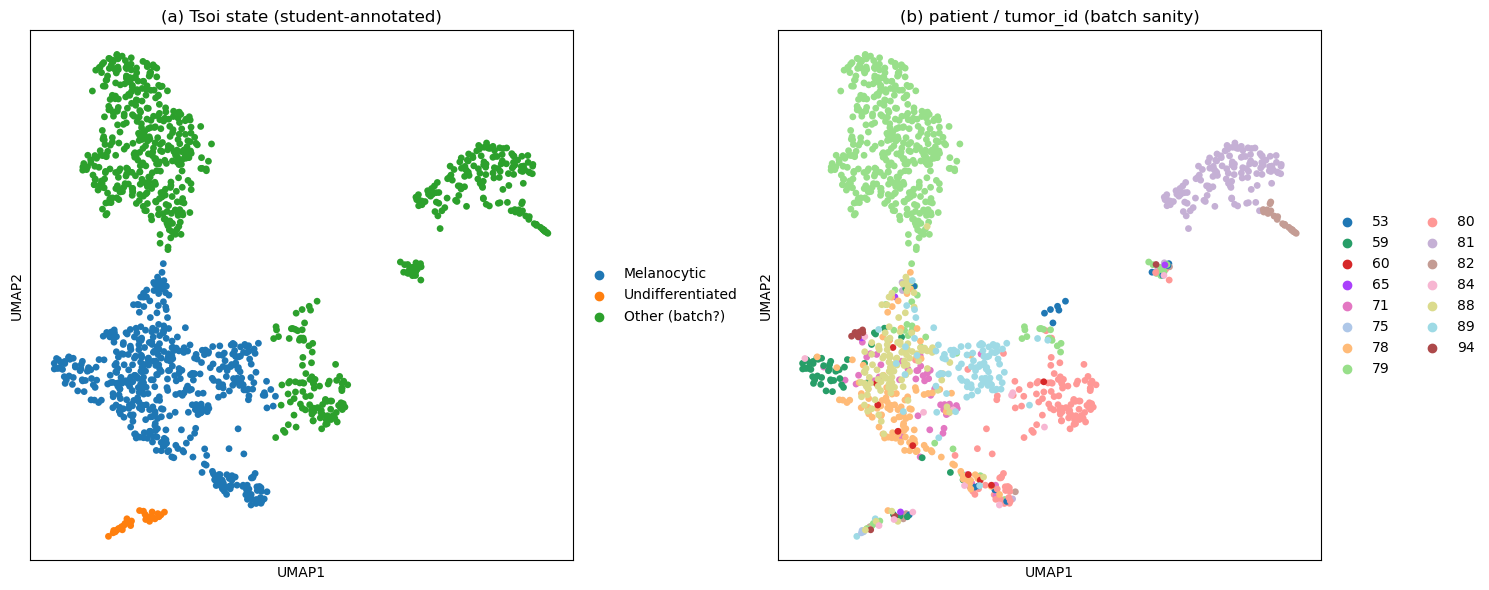

In [9]:
if "tsoi_state" in adata.obs:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    sc.pl.umap(adata, color="tsoi_state", ax=axes[0], show=False,
               title="(a) Tsoi state (student-annotated)")
    sc.pl.umap(adata, color="patient", ax=axes[1], show=False,
               title="(b) patient / tumor_id (batch sanity)")
    plt.tight_layout()
    plt.savefig(FIGDIR / "04_umap_tsoi_vs_patient.png", dpi=130,
                bbox_inches="tight")
    plt.show(); plt.close()
else:
    print("skipped — no tsoi_state yet (fill Step 6).")

### Step 8c — Dotplot by `tsoi_state`

`categories_order` follows the Tsoi differentiation axis (Melanocytic →
Undifferentiated), with `Other (batch?)` last.

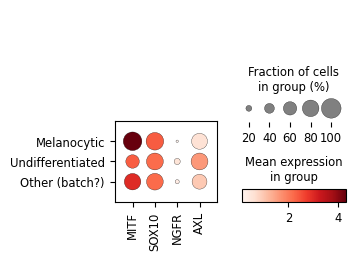

dotplot order: ['Melanocytic', 'Undifferentiated', 'Other (batch?)']


In [10]:
if "tsoi_state" in adata.obs:
    order = list(adata.obs["tsoi_state"].cat.categories)
    sc.pl.dotplot(adata, MARKERS, groupby="tsoi_state",
                  categories_order=order, show=False)
    plt.savefig(FIGDIR / "04_dotplot_by_tsoi_state.png", dpi=130,
                bbox_inches="tight")
    plt.show(); plt.close()
    print("dotplot order:", order)
else:
    print("skipped — no tsoi_state yet (fill Step 6).")

## Step 9 — Save annotated AnnData  *(guarded)*

In [11]:
if "tsoi_state" in adata.obs:
    adata.write_h5ad(OUT_H5AD)
    print(f"Saved: {OUT_H5AD.resolve()} ({OUT_H5AD.stat().st_size/1e6:.1f} MB)")
    chk = sc.read_h5ad(OUT_H5AD)
    assert "tsoi_state" in chk.obs
    print("Reload OK:", chk.shape, "| states:",
          list(chk.obs["tsoi_state"].cat.categories))
else:
    print("NOT saved — annotated h5ad is produced only after Step 6.")

Saved: /Users/youyouwu/Desktop/melanoma-scrnaseq-reanalysis/data/processed/tirosh_malignant_annotated.h5ad (131.9 MB)


Reload OK: (1257, 23686) | states: ['Melanocytic', 'Undifferentiated', 'Other (batch?)']


## Conclusions

**Diagnostics produced (Claude's part):** Leiden at 6 resolutions, the UMAP
grid, a Tsoi-marker dotplot per resolution, and a cluster×patient crosstab
per resolution with patient-domination flags.

**What is the student's part (Step 6):** choose the resolution and assign
Tsoi labels using the dotplot + crosstab *together*, sending
`WARN >0.90 batch?` clusters to `Other (batch?)` and unclear ones to
`Ambiguous`.

**Tie to the open Q2.3 question:** the crosstab is exactly the arbiter for
whether patient 79 / 81–82 are real states or residual batch — if a large
cluster is ~100% one patient with a non-Tsoi marker pattern, that is the
"residual batch → consider raising Harmony theta" signal; if patient 79's
cells split across multiple Tsoi-patterned clusters, the Q2.3 under-mixing
was acceptable. **This judgment is the student's, from the evidence below.**

Status summary is printed next.

In [12]:
print("=" * 62)
print("Q2.4 — DIAGNOSTIC STATUS")
print("=" * 62)
for res in RESOLUTIONS:
    key = f"leiden_r{res}"
    ct = pd.crosstab(adata.obs[key], adata.obs["tumor_id"])
    mx = ct.div(ct.sum(1), axis=0).max(1)
    nbatch = int((mx > 0.90).sum())
    print(f"  res {res:<4} -> {ct.shape[0]:>2} clusters, "
          f"{nbatch} flagged patient-dominated (>0.90)")
print("\nannotated:", "tsoi_state" in adata.obs,
      "-> awaiting student Step 6" if "tsoi_state" not in adata.obs else "")

Q2.4 — DIAGNOSTIC STATUS
  res 0.1  ->  3 clusters, 1 flagged patient-dominated (>0.90)
  res 0.2  ->  5 clusters, 1 flagged patient-dominated (>0.90)
  res 0.3  ->  6 clusters, 1 flagged patient-dominated (>0.90)
  res 0.5  ->  9 clusters, 2 flagged patient-dominated (>0.90)
  res 0.8  -> 11 clusters, 2 flagged patient-dominated (>0.90)
  res 1.0  -> 15 clusters, 5 flagged patient-dominated (>0.90)

annotated: True 


## Tsoi-state annotation — label decision rationale (author)

**Chosen resolution: `leiden_r0.3`** (6 clusters).

### Resolution choice
- **res=0.1** (3 clusters): too coarse — collapses distinct biology together.
- **res=0.3** (6 clusters): best balance — **3 cross-patient biological
  clusters (0, 1, 4)** + **3 patient-dominated batch artifacts (2, 3, 5)**.
- **res ≥ 0.5**: over-clustering — most additional clusters are
  patient-driven (the >0.90 single-patient flag count rises with resolution).

### Cluster-level decisions

**Cluster 0 → Melanocytic.** MITF↑ (4.32), SOX10~ (2.41), NGFR↓ (0.11),
AXL↓ (0.59). Cross-patient (✓ multi-pt, pt88 25%). Textbook Tsoi
melanocytic signature.

**Cluster 1 → Melanocytic.** MITF↑ (4.08), SOX10~ (2.10), NGFR↓ (0.26),
AXL~ (0.71). Cross-patient (✓ multi-pt, pt80 36%). Initially considered
"Transitory" due to slight AXL elevation, but the canonical Transitory
state is defined by NGFR↑, not AXL↑. With NGFR essentially absent (7%
expressing cells), this cluster is best interpreted as a Melanocytic
variant with mild AXL elevation, not Transitory.

**Cluster 2 → Other (batch?).** pt81 73% — exceeds the 70% strict
threshold (Strategy A). Marker pattern (MITF↓ SOX10↓ NGFR~ AXL↓) would
resemble an undifferentiated/intermediate state if not patient-driven;
however, we cannot distinguish biological signal from batch artifact at
this resolution.

**Cluster 3 → Other (batch?).** pt80 78% — exceeds the 70% threshold.
Marker pattern shows the highest NGFR expression in the dataset (0.83),
which is *the* state of interest for distinguishing Transitory / Neural
crest-like. Unfortunately this signal is inseparable from the pt80 patient
effect under Harmony's default theta=2. This is a candidate target for the
scVI re-analysis (Stage 3), where batch conditioning is built into the
model.

**Cluster 4 → Undifferentiated.** MITF↓ (2.35), SOX10~ (2.19), NGFR~
(0.55), AXL↑↑ (1.62 — highest in dataset). Cross-patient (✓ multi-pt,
pt79 21%). Strict Tsoi defines Undifferentiated as SOX10↓ as well, but
SOX10 here is medium rather than low. Considered "Neural crest-like" as an
alternative, but NGFR is too low (0.55, 21% expressing) to support that
label. Caveat: n=33 cells — small sample size limits the statistical
robustness of this annotation.

**Cluster 5 → Other (batch?).** pt79 100% — definitive batch artifact.
Marker pattern (MITF~ SOX10~ AXL~) is internally consistent but cannot be
biologically interpreted given complete patient confounding.

### Methodological caveats (for the Stage 2 mini-report)

1. **NGFR signal is broadly weak across the dataset** (mean expression
   < 0.85 in all clusters; < 25% expressing cells in all but a few). This
   makes Transitory and Neural crest-like states essentially
   indistinguishable in Tirosh 2016 data using marker-based annotation.
   Consequently we recover at most 2 of the canonical 4 Tsoi states.
2. **Harmony with default theta=2 under-corrects for high-cell-count
   patients** (pt79, pt80, pt81). 3 of 6 clusters are patient-dominated
   (>70%), suggesting either residual batch effect or genuine
   patient-specific biology (CNV, clonal genetics) that Harmony cannot
   separate from technical variance.
3. **Sample-size imbalance** (pt79 n=896 vs pt65 n=63, ~14× range) likely
   contributes to the observed batch persistence.

These caveats define the entry point for **Stage 3 (scVI/scANVI)**, which
uses explicit batch conditioning in a non-linear latent space and may
resolve some of the patient-dominated clusters into biologically
interpretable states.